# Case study: car prices in the US market

From the week 4 supervised practice session (the original was shared as a PDF). The setup:

> A car company wants to enter the US market and build cars locally. Using data on cars sold there, which
> variables are significant in predicting price, and how well do they describe it? Management will use
> the model to understand how price varies with each variable and plan designs and pricing around it.

So the goal is a model that predicts well **and** can be interpreted. The session was organised as
question sets, which are kept as section headings here.

Data: [Car Price Prediction on Kaggle](https://www.kaggle.com/datasets/hellbuoy/car-price-prediction)
(`CarPrice_Assignment.csv`, 205 cars, 26 columns).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=ConvergenceWarning)   # lasso at tiny alphas during the search

In [2]:
# in Colab: upload the csv first
# from google.colab import files; files.upload()
dataset = pd.read_csv('CarPrice_Assignment.csv')
dataset.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Question set 1: inspection

(i) data points, (ii) features, (iii) categorical, (iv) numerical, (v) missing values, (vi) list of
features, (vii) duplicates

In [3]:
num_feat = dataset.select_dtypes(include='number').columns.tolist()
cat_feat = dataset.select_dtypes(exclude='number').columns.tolist()

print("data points:        ", dataset.shape[0])
print("columns:            ", dataset.shape[1], "(25 features + price)")
print("categorical columns:", len(cat_feat))
print("numerical columns:  ", len(num_feat), "(including car_ID and price)")
print("missing values:     ", dataset.isna().sum().sum())
print("duplicate rows:     ", dataset.duplicated().sum())

data points:         205
columns:             26 (25 features + price)
categorical columns: 10
numerical columns:   16 (including car_ID and price)
missing values:      0
duplicate rows:      0


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

Small and clean: 205 rows, nothing missing, no duplicates. `car_ID` is just a row number, so it's not a
real feature and gets dropped before modelling.

## Question set 2: exploratory analysis

In [5]:
print('numeric:', num_feat)
print('categorical:', cat_feat)

numeric: ['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']
categorical: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [6]:
dataset.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
car_ID,205.0,103.00,59.32,1.00,52.00,103.00,154.00,205.00
symboling,205.0,0.83,1.25,-2.00,0.00,1.00,2.00,3.00
wheelbase,205.0,98.76,6.02,86.60,94.50,97.00,102.40,120.90
carlength,205.0,174.05,12.34,141.10,166.30,173.20,183.10,208.10
carwidth,205.0,65.91,2.15,60.30,64.10,65.50,66.90,72.30
carheight,205.0,53.72,2.44,47.80,52.00,54.10,55.50,59.80
curbweight,205.0,2555.57,520.68,1488.00,2145.00,2414.00,2935.00,4066.00
enginesize,205.0,126.91,41.64,61.00,97.00,120.00,141.00,326.00
boreratio,205.0,3.33,0.27,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.26,0.31,2.07,3.11,3.29,3.41,4.17


### Distribution of price

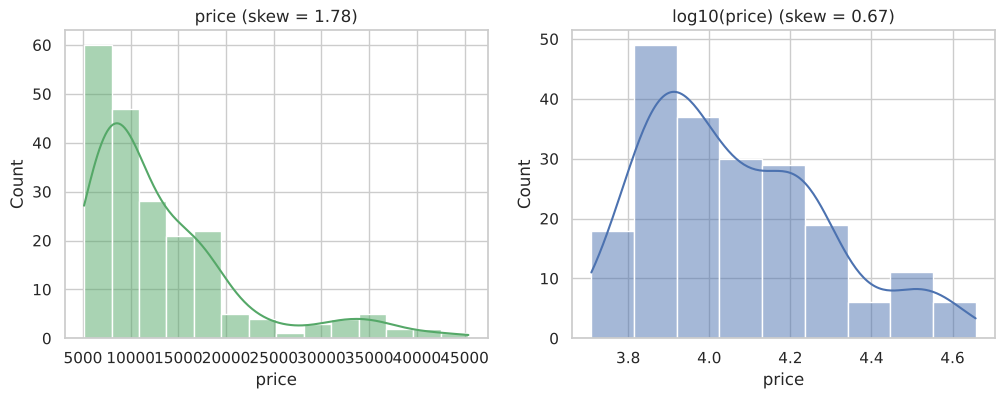

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(dataset['price'], kde=True, ax=axes[0], color='g')
axes[0].set_title(f"price (skew = {dataset['price'].skew():.2f})")
sns.histplot(np.log10(dataset['price']), kde=True, ax=axes[1])
axes[1].set_title(f"log10(price) (skew = {np.log10(dataset['price']).skew():.2f})")
plt.show()

Price is right-skewed: most cars are under $20k with a tail of expensive ones up to $45k. On a log scale
it's much more symmetric. (`sns.distplot` from the original is deprecated, `histplot` is the replacement.)

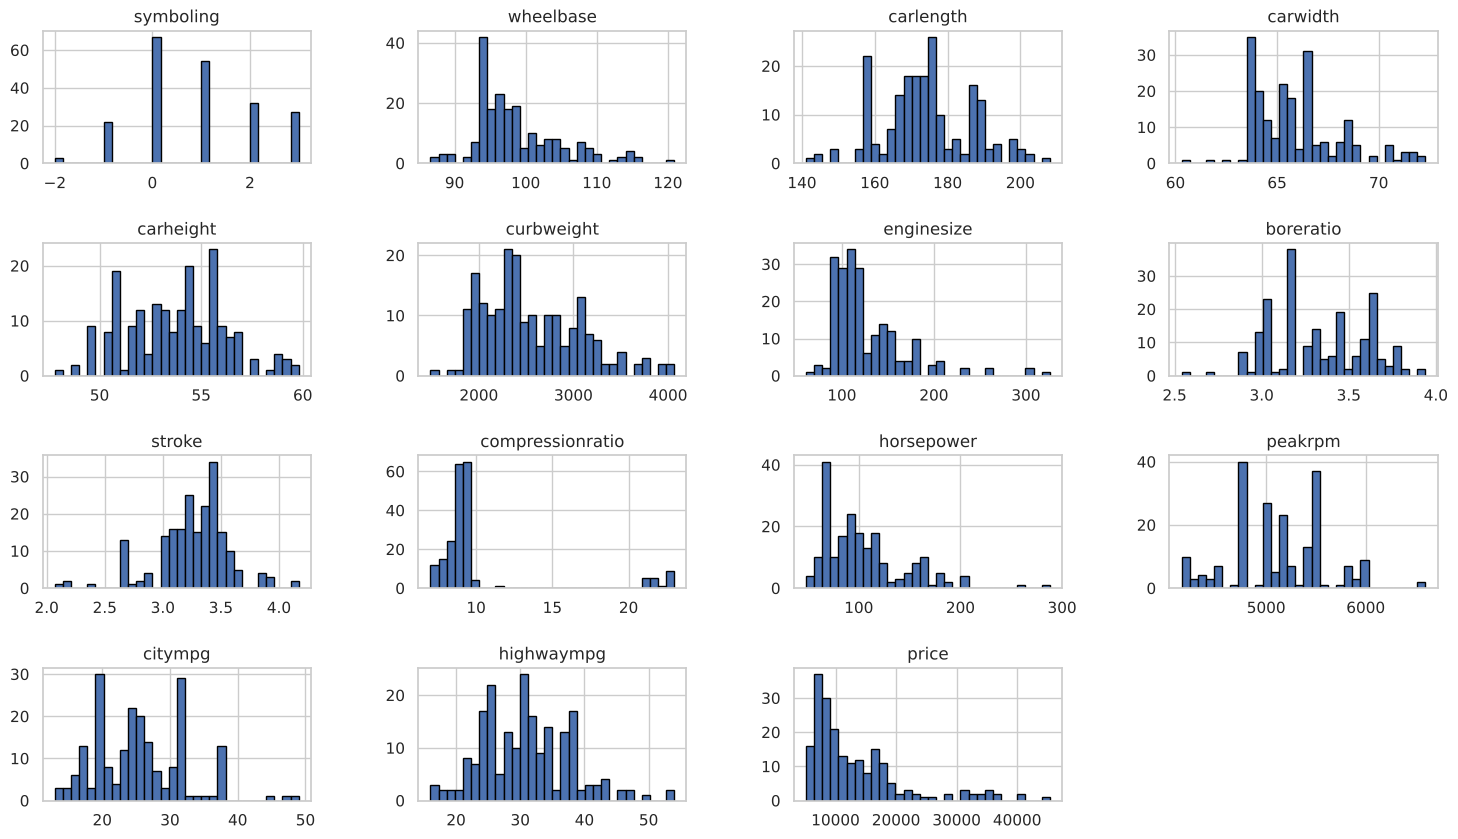

In [8]:
dataset[num_feat].drop(columns=['car_ID']).hist(figsize=(18, 10), bins=30, edgecolor='black')
plt.subplots_adjust(hspace=0.6, wspace=0.4)
plt.show()

**Is scaling needed?** Yes. `curbweight` is in the thousands, `peakrpm` around 5,000, `boreratio` and
`stroke` around 3. That matters for the regularised models (the penalty treats all coefficients equally)
and for comparing coefficient sizes. `compressionratio` is bimodal: most cars are around 9-10, and a
separate group at 21-23 (the diesels).

### Categorical features

In [9]:
for col in cat_feat:
    if col == 'CarName':
        continue
    print(f"{col:15s}", dataset[col].value_counts().to_dict())

fueltype        {'gas': 185, 'diesel': 20}
aspiration      {'std': 168, 'turbo': 37}
doornumber      {'four': 115, 'two': 90}
carbody         {'sedan': 96, 'hatchback': 70, 'wagon': 25, 'hardtop': 8, 'convertible': 6}
drivewheel      {'fwd': 120, 'rwd': 76, '4wd': 9}
enginelocation  {'front': 202, 'rear': 3}
enginetype      {'ohc': 148, 'ohcf': 15, 'ohcv': 13, 'dohc': 12, 'l': 12, 'rotor': 4, 'dohcv': 1}
cylindernumber  {'four': 159, 'six': 24, 'five': 11, 'eight': 5, 'two': 4, 'three': 1, 'twelve': 1}
fuelsystem      {'mpfi': 94, '2bbl': 66, 'idi': 20, '1bbl': 11, 'spdi': 9, '4bbl': 3, 'mfi': 1, 'spfi': 1}


* `enginelocation` is front for all but 3 cars, so it carries very little information.
* `fuelsystem` has categories with a single car (mfi, spfi), and `enginetype` / `cylindernumber` are
  dominated by one value (ohc, four).
* `doornumber` and `cylindernumber` are numbers written as words, so they can be converted directly.

### Words to numbers

In [10]:
WORDS = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}

def words_to_num(series):
    return series.map(WORDS)

words_to_num(dataset['cylindernumber']).value_counts().sort_index()

cylindernumber
2       4
3       1
4     159
5      11
6      24
8       5
12      1
Name: count, dtype: int64

### Car brands

`CarName` is brand + model. The model names are nearly unique, but the brand is useful. There are some
typos to clean up (`toyouta`, `vokswagen`, `vw`, `maxda`, `porcshce`).

In [11]:
df = dataset.copy()
df['company'] = (df['CarName'].str.split(' ').str[0]
                 .replace({'toyouta': 'toyota', 'vw': 'volkswagen', 'vokswagen': 'volkswagen',
                           'maxda': 'mazda', 'porcshce': 'porsche', 'Nissan': 'nissan'})
                 .str.title())
print("brands:", df['company'].nunique())
df['company'].value_counts().head(10)

brands: 22


company
Toyota        32
Nissan        18
Mazda         17
Honda         13
Mitsubishi    13
Subaru        12
Volkswagen    12
Peugeot       11
Volvo         11
Dodge          9
Name: count, dtype: int64

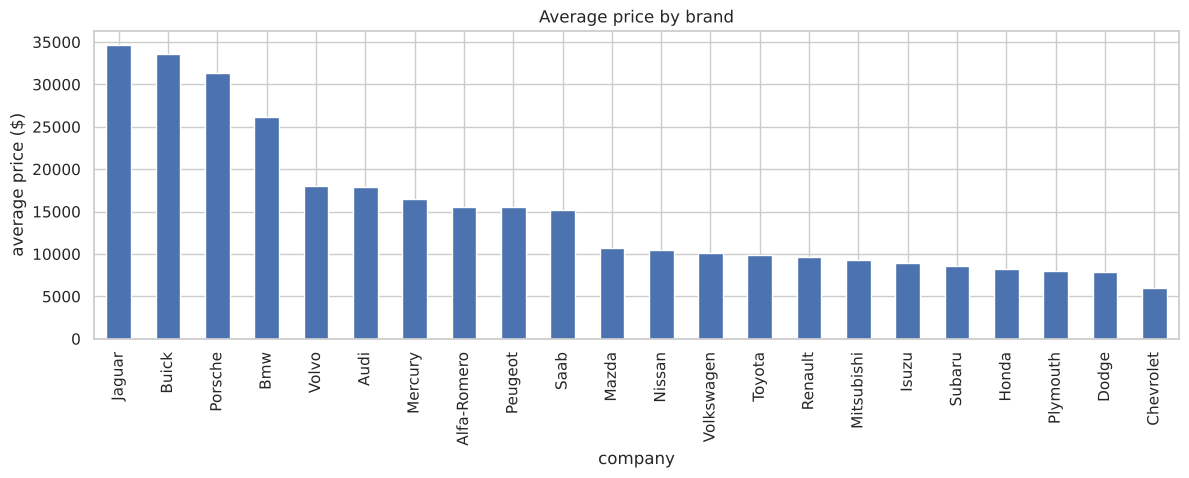

average Jaguar price: $34,600


In [12]:
brand_price = df.groupby('company')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)

brand_price['mean'].plot.bar(figsize=(14, 4))
plt.ylabel('average price ($)'); plt.title('Average price by brand')
plt.show()

print(f"average Jaguar price: ${brand_price.loc['Jaguar', 'mean']:,.0f}")

Jaguar, Buick, Porsche and BMW are the expensive brands. Brand clearly matters for price, though several
brands only have 1-5 cars, so the averages for those are rough.

## Question set 3: correlation and multicollinearity

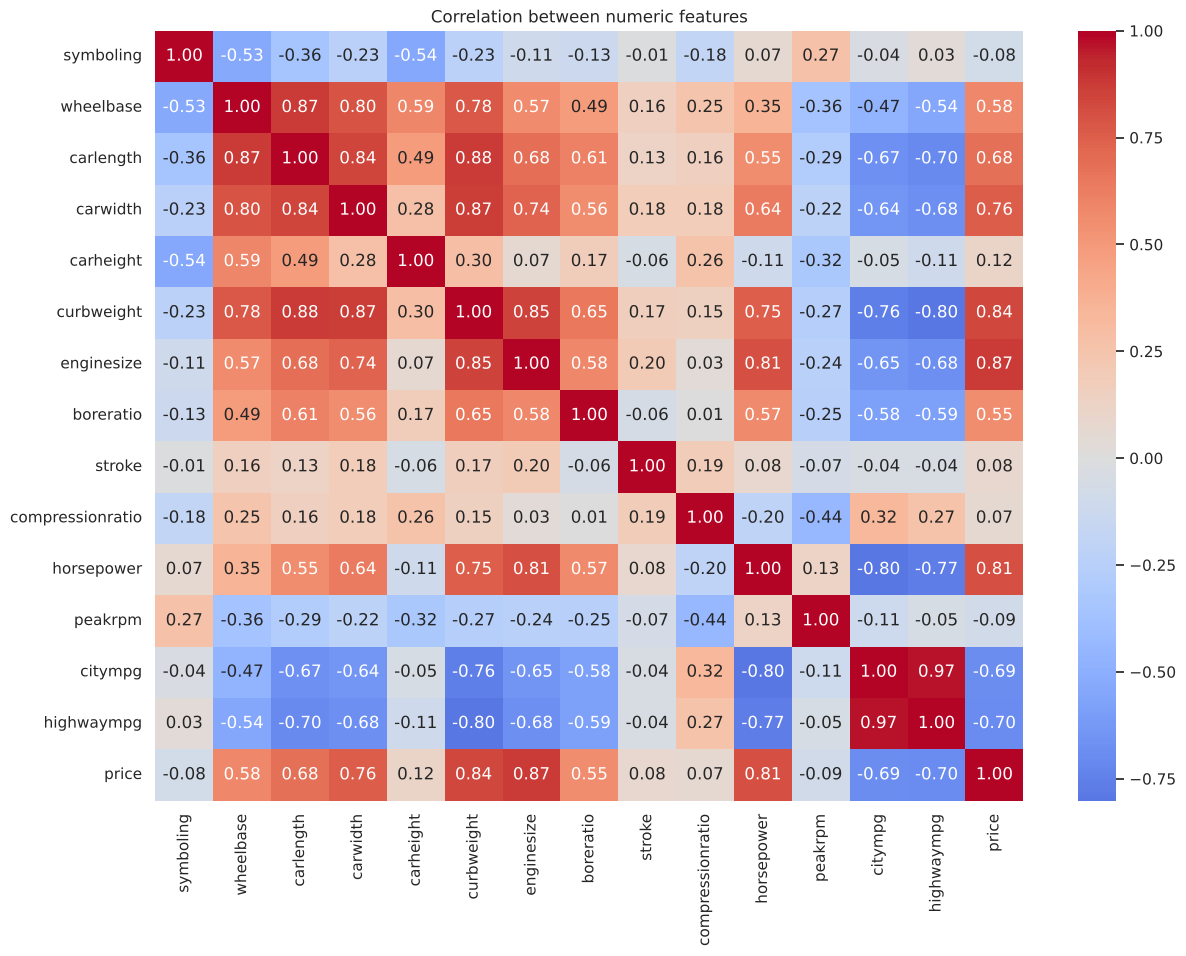

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(dataset[num_feat].drop(columns='car_ID').corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between numeric features')
plt.show()

In [14]:
dataset[num_feat].drop(columns='car_ID').corr()['price'].drop('price').sort_values(ascending=False).round(2)

enginesize          0.87
curbweight          0.84
horsepower          0.81
carwidth            0.76
carlength           0.68
wheelbase           0.58
boreratio           0.55
carheight           0.12
stroke              0.08
compressionratio    0.07
symboling          -0.08
peakrpm            -0.09
citympg            -0.69
highwaympg         -0.70
Name: price, dtype: float64

Engine size, curb weight, horsepower, width and length are all strongly correlated with price, but also
with each other (bigger cars have bigger, more powerful engines and use more fuel). `citympg` and
`highwaympg` are almost the same thing (r = 0.97).

When features are this correlated, a linear model can't tell their effects apart, and the individual
coefficients become unstable and hard to interpret. The **variance inflation factor (VIF)** measures this
per feature: regress that feature on all the others, and VIF = 1 / (1 - R2). A VIF above 5 (or 10) is
usually treated as a problem.

In [15]:
def make_vif_df(X):
    Xc = add_constant(X)
    vif = [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])]
    return pd.DataFrame({'variables': X.columns, 'VIF': vif}).sort_values('VIF', ascending=False)

numeric_X = dataset[num_feat].drop(columns=['car_ID', 'price'])
vif_df = make_vif_df(numeric_X)
vif_df.round(1)

,variables,VIF
12,citympg,27.8
13,highwaympg,24.4
5,curbweight,16.4
2,carlength,9.4
1,wheelbase,8.4
10,horsepower,8.3
6,enginesize,6.7
3,carwidth,5.7
4,carheight,2.3
9,compressionratio,2.2


The constant is added before computing VIF, otherwise the numbers come out inflated (the course version
skipped this).

Now remove the worst feature one at a time and recompute, until everything is below 10:

In [16]:
def drop_high_vif(X, threshold=10):
    X = X.copy()
    dropped = []
    while True:
        vif = make_vif_df(X)
        worst = vif.iloc[0]
        if worst['VIF'] < threshold:
            return X, dropped, vif
        dropped.append((worst['variables'], round(float(worst['VIF']), 1)))
        X = X.drop(columns=worst['variables'])

reduced_X, dropped, final_vif = drop_high_vif(numeric_X)
print("dropped (feature, VIF when dropped):", dropped)
final_vif.round(1)

dropped (feature, VIF when dropped): [('citympg', 27.8), ('curbweight', 16.4)]


,variables,VIF
2,carlength,8.0
1,wheelbase,8.0
9,horsepower,6.9
5,enginesize,5.6
3,carwidth,5.6
11,highwaympg,4.5
4,carheight,2.3
6,boreratio,2.1
10,peakrpm,2.0
0,symboling,1.8


Dropping just a couple of features is enough to get everything under 10. Whether to actually drop them
depends on the goal: for pure prediction, multicollinearity isn't a big problem (and ridge handles it).
For interpreting individual coefficients, which is what management asked for, it is.

## Encoding

In [17]:
data = df.drop(columns=['car_ID', 'CarName'])

data['doornumber'] = words_to_num(data['doornumber'])
data['cylindernumber'] = words_to_num(data['cylindernumber'])
data['fueltype'] = (data['fueltype'] == 'diesel').astype(int)
data['aspiration'] = (data['aspiration'] == 'turbo').astype(int)
data['enginelocation'] = (data['enginelocation'] == 'rear').astype(int)

data = pd.get_dummies(data, columns=['carbody', 'drivewheel', 'enginetype', 'fuelsystem', 'company'],
                      drop_first=True, dtype=int)
data.shape

(205, 60)

Differences from the original:

* `car_ID` is dropped. The original kept it as a feature, but it's only a row number (it happens to be
  sorted by brand, so it leaks a bit of brand information in a meaningless way).
* `enginelocation` was mapped with `{"front": 0, "back": 1}`, but the value in the data is `"rear"`, so
  the mapping silently did nothing and the column then got one-hot encoded with odd names.
* `drivewheel` was mapped to fwd=0, 4wd=0, rwd=1, which merges two categories. One-hot keeps them apart.
* `drop_first=True` drops one dummy per category. With all dummies plus an intercept, the dummy columns
  add up to the intercept column exactly (perfect multicollinearity), which is why the original linear
  model had a coefficient of exactly 0 and pairs of identical coefficients.
* `company` is included, since the EDA showed brand matters a lot.

## Split

In [18]:
X = data.drop(columns='price')
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape

((164, 59), (41, 59))

## Question set 4: models

Linear regression, lasso, ridge and elastic net, each with standard scaling in front. The regularisation
strength is tuned with 5-fold CV on the training set.

With only 41 test cars, a single test score is noisy, so I also report the cross-validated R2 on the
training set.

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
alphas = np.logspace(-2, 4, 25)

searches = {
    'linear regression': make_pipeline(StandardScaler(), LinearRegression()),
    'lasso': GridSearchCV(make_pipeline(StandardScaler(), Lasso(max_iter=50000)),
                          {'lasso__alpha': alphas}, cv=kf, scoring='neg_mean_squared_error'),
    'ridge': GridSearchCV(make_pipeline(StandardScaler(), Ridge()),
                          {'ridge__alpha': alphas}, cv=kf, scoring='neg_mean_squared_error'),
    'elastic net': GridSearchCV(make_pipeline(StandardScaler(), ElasticNet(max_iter=50000)),
                                {'elasticnet__alpha': np.logspace(-3, 2, 15),
                                 'elasticnet__l1_ratio': [0.1, 0.5, 0.9]},
                                cv=kf, scoring='neg_mean_squared_error'),
}

rows = []
for name, model in searches.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    best = model.best_estimator_ if hasattr(model, 'best_estimator_') else model
    rows.append({
        'model': name,
        'best params': getattr(model, 'best_params_', '-'),
        'CV R2 (train)': cross_val_score(best, X_train, y_train, cv=kf, scoring='r2').mean(),
        'train R2': r2_score(y_train, model.predict(X_train)),
        'test R2': r2_score(y_test, pred),
        'test RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results = pd.DataFrame(rows).set_index('model')
results.round(3)

,best params,CV R2 (train),train R2,test R2,test RMSE
model,,,,,
linear regression,-,0.914,0.975,0.861,3275.769
lasso,{'lasso__alpha': 100.0},0.928,0.957,0.859,3301.836
ridge,{'ridge__alpha': 10.0},0.931,0.966,0.852,3389.661
elastic net,"{'elasticnet__alpha': 0.13894954943731375, 'el...",0.931,0.965,0.850,3404.060


Elastic net combines both penalties:

$$\alpha \left( \text{l1\_ratio} \cdot \|w\|_1 + \tfrac{1}{2}(1 - \text{l1\_ratio}) \|w\|_2^2 \right)$$

so `l1_ratio=1` is lasso and `l1_ratio=0` is ridge.

### Log of price

Price was skewed, so it's worth trying the models on log(price). `TransformedTargetRegressor` handles the
transform and converts predictions back to dollars:

In [20]:
log_ridge = TransformedTargetRegressor(
    regressor=GridSearchCV(make_pipeline(StandardScaler(), Ridge()), {'ridge__alpha': alphas},
                           cv=kf, scoring='neg_mean_squared_error'),
    func=np.log, inverse_func=np.exp)
log_ridge.fit(X_train, y_train)
pred = log_ridge.predict(X_test)
print(f"ridge on log(price): test R2 = {r2_score(y_test, pred):.3f}, "
      f"test RMSE = {np.sqrt(mean_squared_error(y_test, pred)):,.0f}")

ridge on log(price): test R2 = 0.865, test RMSE = 3,233


### Which variables matter?

The lasso coefficients are the easiest to read, since it sets unhelpful ones to zero. With scaled
features, each coefficient is the change in price (in $) for a one standard deviation change in that
feature.

non-zero coefficients: 32 of 59


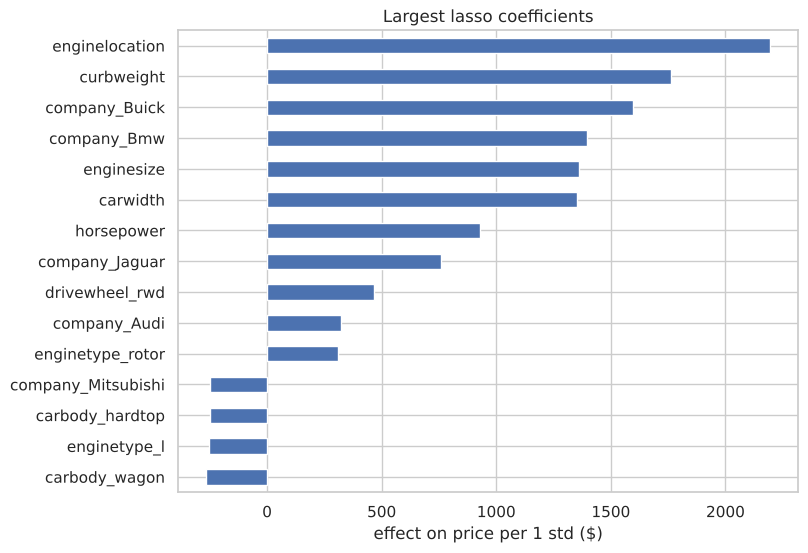

In [21]:
lasso_best = searches['lasso'].best_estimator_
coefs = pd.Series(lasso_best[-1].coef_, index=X.columns)
print(f"non-zero coefficients: {(coefs != 0).sum()} of {len(coefs)}")

top = coefs[coefs != 0].sort_values(key=abs, ascending=False).head(15)
top.sort_values().plot.barh(figsize=(8, 6))
plt.xlabel('effect on price per 1 std ($)')
plt.title('Largest lasso coefficients')
plt.show()

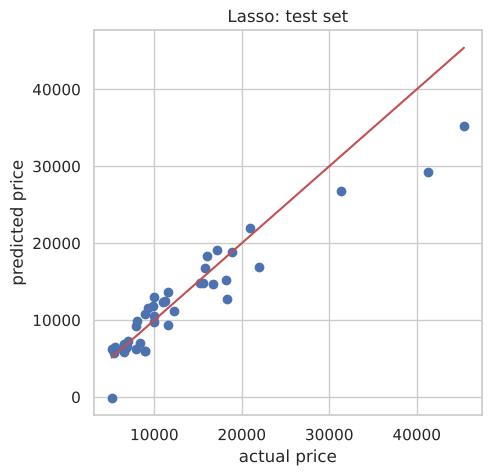

In [22]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, searches['lasso'].predict(X_test))
lims = [y.min(), y.max()]
plt.plot(lims, lims, 'r-')
plt.xlabel('actual price'); plt.ylabel('predicted price')
plt.title('Lasso: test set')
plt.show()

## Observations

* All four models explain most of the variation in price: R2 of 0.91-0.93 in cross validation and about
  0.85-0.86 on the 41 test cars. Size and power (curb weight, engine size, horsepower, width) and brand
  are the main drivers.
* The plain linear model has a big gap between train and test R2. With 60+ columns for 164 training
  cars, there are a lot of parameters for not much data, and regularisation narrows that gap.
* Lasso keeps 32 of the 59 columns and gets similar accuracy, which is more useful for the
  "which variables are significant" part of the question.
* Brand dummies come out as some of the largest effects. That's realistic (a BMW costs more than a Toyota
  with the same engine), but for a new company entering the market it's the physical specs that it
  can actually design around.
* Because size, weight, engine and power are all correlated, individual coefficients should be read with
  care. The VIF analysis shows which ones overlap.
* The test set is small (41 cars), so differences of a few hundredths in R2 between models aren't
  meaningful. The CV column is a more reliable comparison, and there the regularised models come out
  slightly ahead of plain linear regression.
* Modelling log(price) does about as well. It has the advantage that predictions can never be negative.